In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/steam_games_feature.csv")
df.head()


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Full audio languages,Windows,...,review_log,review_balance,price_log,owners_log,is_free,main_genre,main_category,rating_gap,release_decade,is_recent
0,Galactic Bowling,2008-10-21,0 - 20000,0,0,19.99,0,['English'],[],True,...,2.890372,-0.277778,3.044046,9.21044,0,Casual,Single-player,0,2000,0
1,Train Bandit,2017-10-12,0 - 20000,0,0,0.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,4.077537,0.813559,0.688135,9.21044,0,Action,Single-player,0,2010,0
2,Jolt Project,2021-11-17,0 - 20000,0,0,4.99,0,"['English', 'Portuguese - Brazil']",[],True,...,0.000000,0.000000,1.790091,9.21044,0,Action,Single-player,0,2020,1
3,Henosis™,2020-07-23,0 - 20000,0,0,5.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,1.386294,0.750000,1.944481,9.21044,0,Adventure,Single-player,0,2020,1
4,Two Weeks in Painland,2020-02-03,0 - 20000,0,0,0.00,0,"['English', 'Spanish - Spain']",[],True,...,4.077537,0.711864,0.000000,9.21044,1,Adventure,Single-player,0,2020,1


In [3]:
df.describe(include='all')

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Full audio languages,Windows,...,review_log,review_balance,price_log,owners_log,is_free,main_genre,main_category,rating_gap,release_decade,is_recent
count,82842,82842,82842,82842.000000,82842.000000,82842.000000,82842.000000,82842,82842,82842,...,82842.000000,82842.000000,82842.000000,82842.000000,82842.000000,82842,82842,82842.000000,82842.000000,82842.000000
unique,82842,4360,14,NaN,NaN,NaN,NaN,11098,2197,2,...,NaN,NaN,NaN,NaN,NaN,28,26,NaN,NaN,NaN
top,Galactic Bowling,2023-07-14,0 - 20000,NaN,NaN,NaN,NaN,['English'],[],True,...,NaN,NaN,NaN,NaN,NaN,Action,Single-player,NaN,NaN,NaN
freq,1,101,54046,NaN,NaN,NaN,NaN,42407,48145,82812,...,NaN,NaN,NaN,NaN,NaN,32510,74423,NaN,NaN,NaN
mean,NaN,NaN,NaN,133.873361,0.308237,7.199594,0.518095,NaN,NaN,NaN,...,2.722895,0.343337,1.560769,8.523601,0.192282,NaN,NaN,-3.319138,2015.934188,0.601869
std,NaN,NaN,NaN,5442.323951,2.237485,12.321096,13.080760,NaN,NaN,NaN,...,2.425379,0.405713,1.061971,3.450531,0.394096,NaN,NaN,15.545827,5.082524,0.489516
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,-0.962963,0.000000,0.000000,0.000000,NaN,NaN,-97.000000,1990.000000,0.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.990000,0.000000,NaN,NaN,NaN,...,0.693147,0.000000,0.688135,9.210440,0.000000,NaN,NaN,0.000000,2010.000000,0.000000
50%,NaN,NaN,NaN,0.000000,0.000000,4.610000,0.000000,NaN,NaN,NaN,...,2.397895,0.395797,1.724551,9.210440,0.000000,NaN,NaN,0.000000,2020.000000,1.000000
75%,NaN,NaN,NaN,1.000000,0.000000,9.990000,0.000000,NaN,NaN,NaN,...,4.174387,0.703162,2.396986,9.210440,0.000000,NaN,NaN,0.000000,2020.000000,1.000000


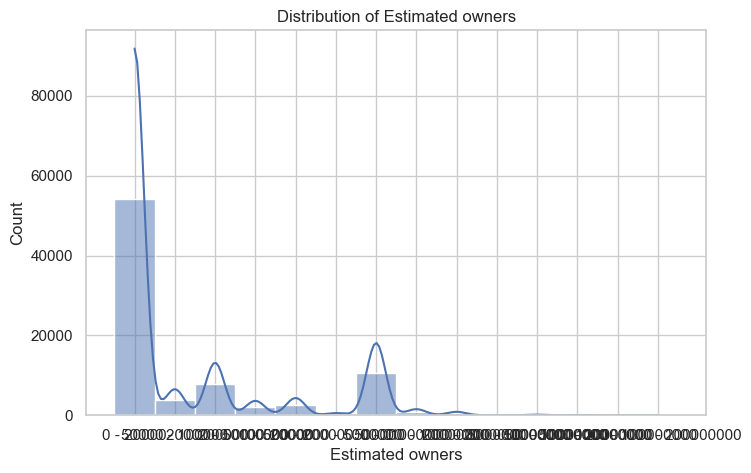

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated owners"], kde=True, bins=40)
plt.title("Distribution of Estimated owners")
plt.show()

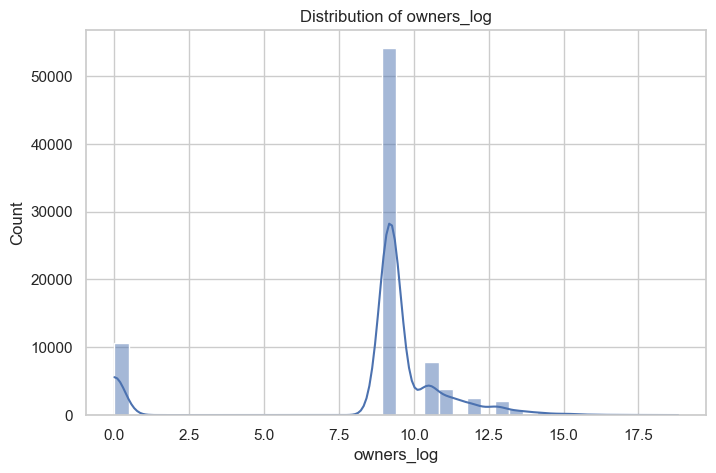

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["owners_log"], kde=True, bins=40)
plt.title("Distribution of owners_log")
plt.show()


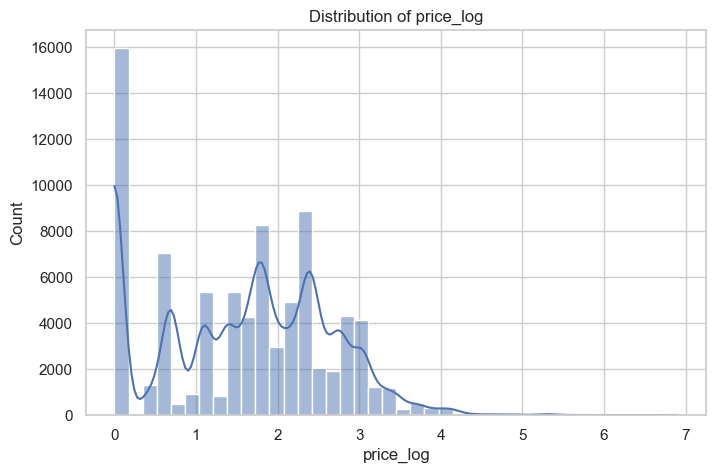

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["price_log"], kde=True, bins=40)
plt.title("Distribution of price_log")
plt.show()


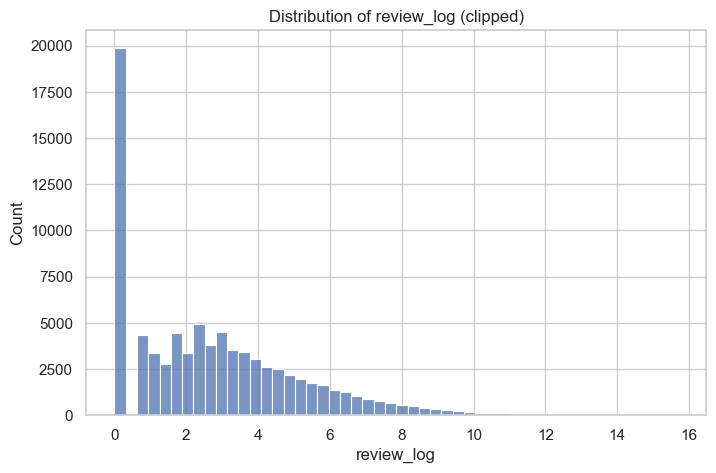

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["review_log"], kde=False, bins=50)
plt.title("Distribution of review_log (clipped)")
plt.show()


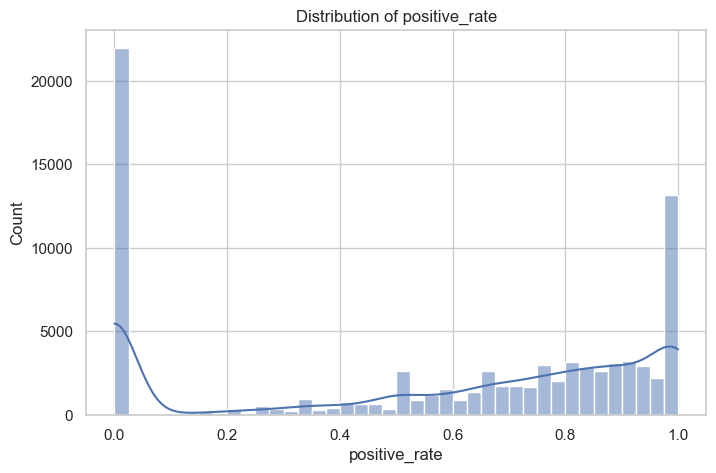

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["positive_rate"], kde=True, bins=40)
plt.title("Distribution of positive_rate")
plt.show()


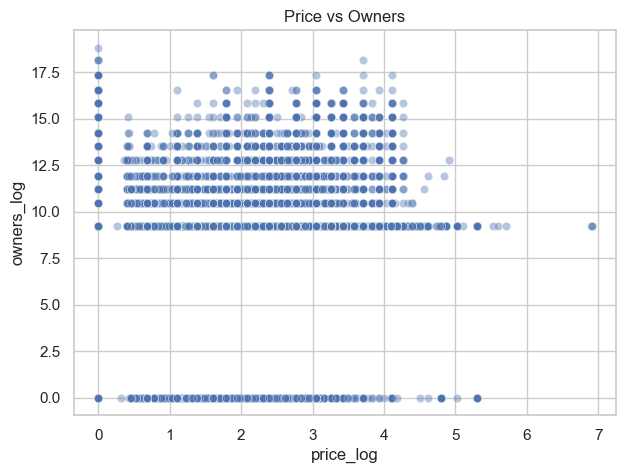

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="price_log", y="owners_log", data=df, alpha=0.4)
plt.title("Price vs Owners")
plt.show()


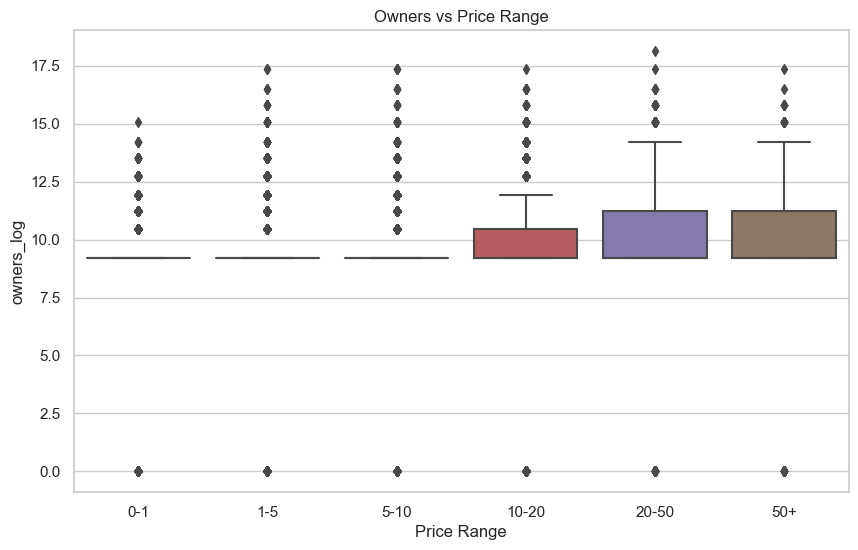

In [10]:
df["price_bin"] = pd.cut(df["Price"], bins=[0,1,5,10,20,50,200],
                         labels=["0-1","1-5","5-10","10-20","20-50","50+"])

plt.figure(figsize=(10,6))
sns.boxplot(x="price_bin", y="owners_log", data=df)
plt.title("Owners vs Price Range")
plt.xlabel("Price Range")
plt.ylabel("owners_log")
plt.show()


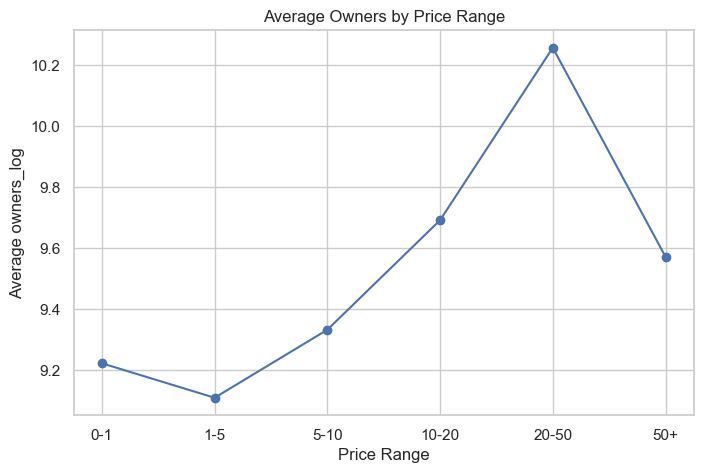

In [11]:
price_trend = df.groupby("price_bin")["owners_log"].mean()

price_trend.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Average Owners by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average owners_log")
plt.show()


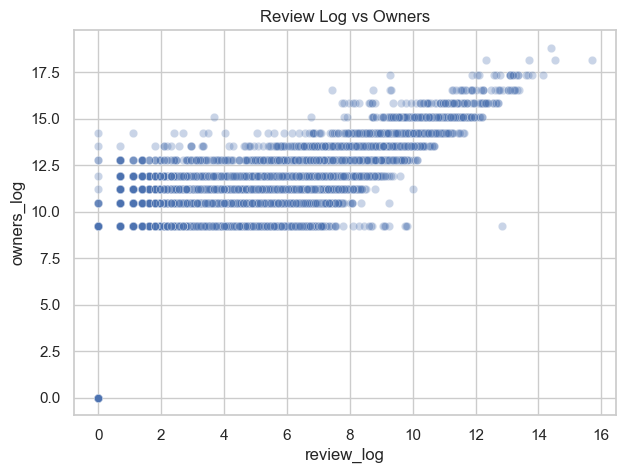

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="review_log", y="owners_log", data=df, alpha=0.3)
plt.title("Review Log vs Owners")
plt.show()


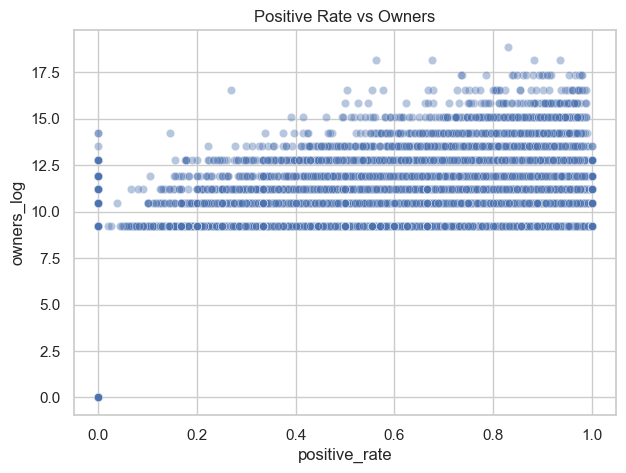

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="positive_rate", y="owners_log", data=df, alpha=0.4)
plt.title("Positive Rate vs Owners")
plt.show()


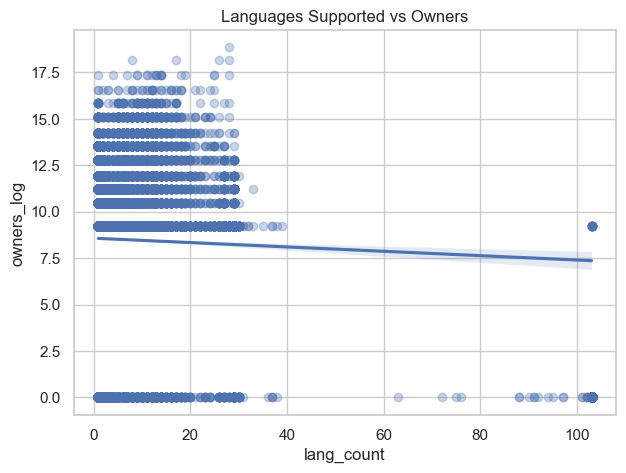

In [14]:
plt.figure(figsize=(7,5))
sns.regplot(x="lang_count", y="owners_log", data=df, scatter_kws={'alpha':0.3})
plt.title("Languages Supported vs Owners")
plt.show()


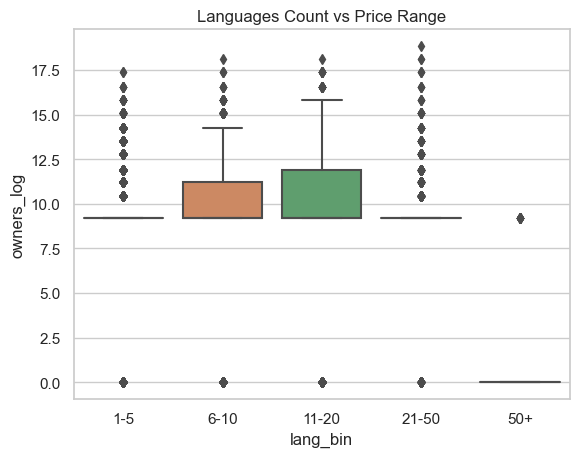

In [15]:
df["lang_bin"] = pd.cut(df["lang_count"], bins=[0,5,10,20,50,200],
                        labels=["1-5","6-10","11-20","21-50","50+"])

sns.boxplot(x="lang_bin", y="owners_log", data=df)

plt.title("Languages Count vs Price Range")
plt.xlabel("lang_bin")
plt.ylabel("owners_log")
plt.show()


<Axes: xlabel='lang_bin'>

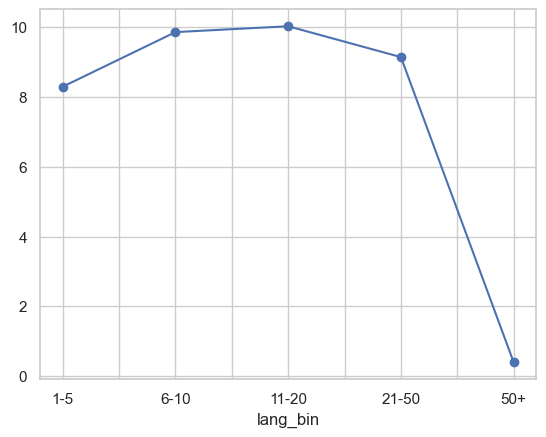

In [16]:
lang_trend = df.groupby("lang_bin")["owners_log"].mean()
lang_trend.plot(marker="o")


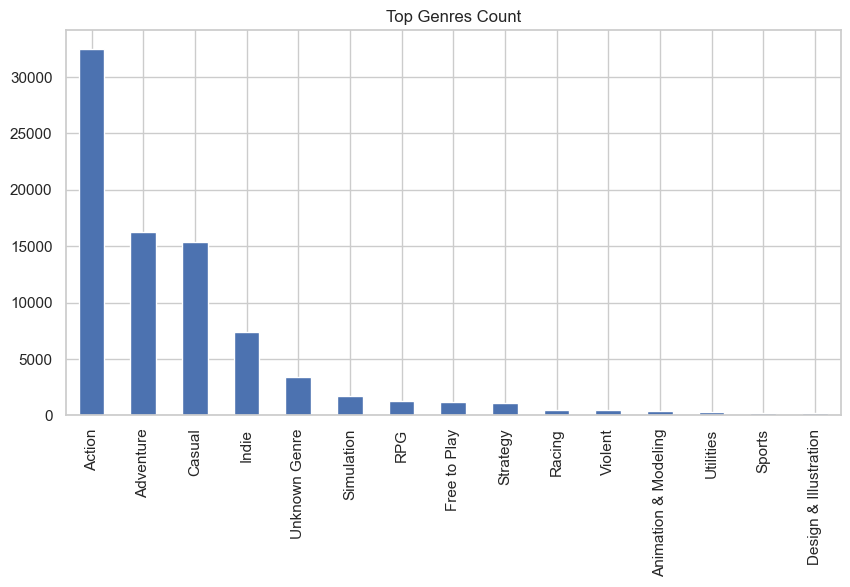

In [17]:
plt.figure(figsize=(10,5))
df["main_genre"].value_counts().head(15).plot(kind="bar")
plt.title("Top Genres Count")
plt.show()


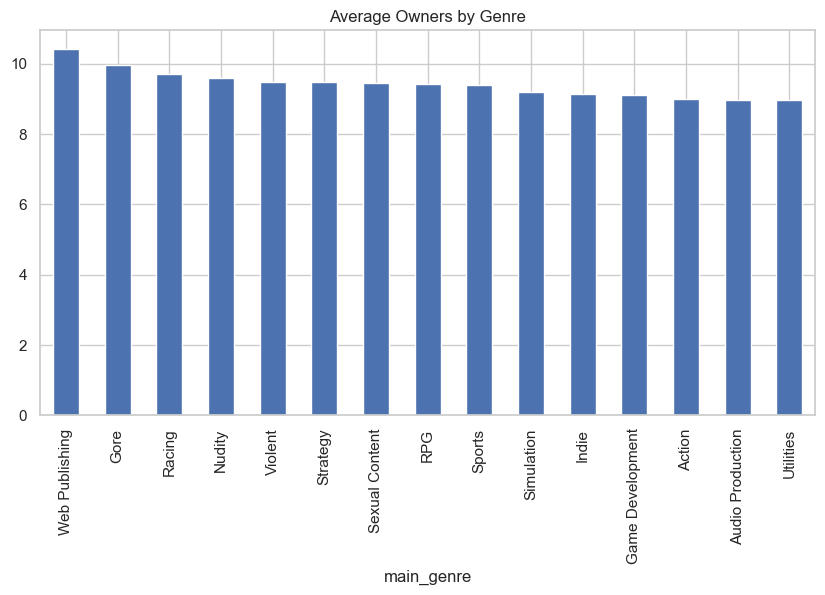

In [18]:
plt.figure(figsize=(10,5))
df.groupby("main_genre")["owners_log"].mean().sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Average Owners by Genre")
plt.show()


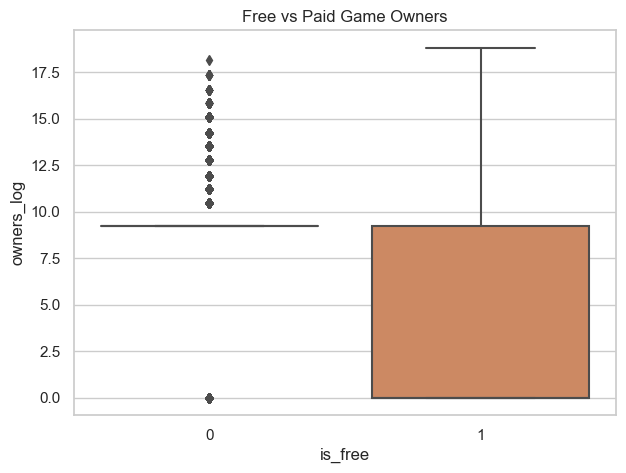

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["is_free"].astype(str), y=df["owners_log"])
plt.title("Free vs Paid Game Owners")
plt.show()


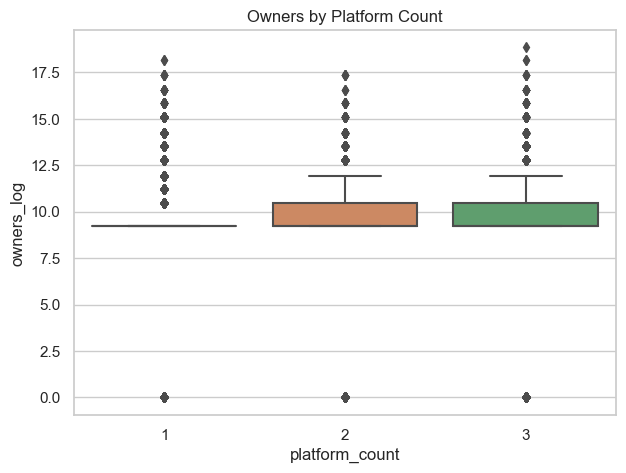

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x="platform_count", y="owners_log", data=df)
plt.title("Owners by Platform Count")
plt.show()


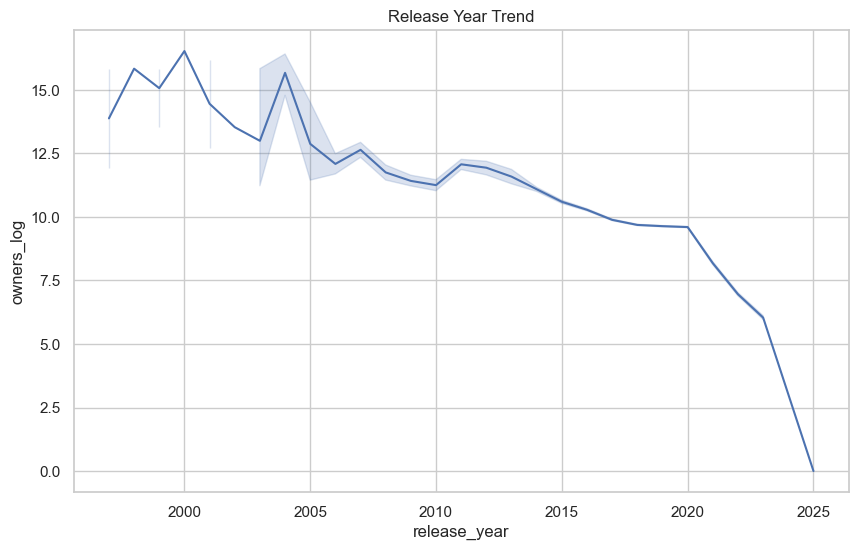

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(x="release_year", y="owners_log", data=df)
plt.title("Release Year Trend")
plt.show()


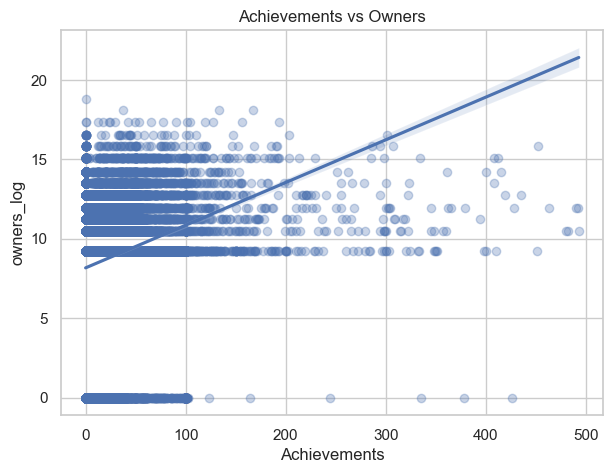

In [22]:

plt.figure(figsize=(7,5))
sns.regplot(x="Achievements", y="owners_log", data=df, scatter_kws={'alpha':0.3})
plt.title("Achievements vs Owners")
plt.show()


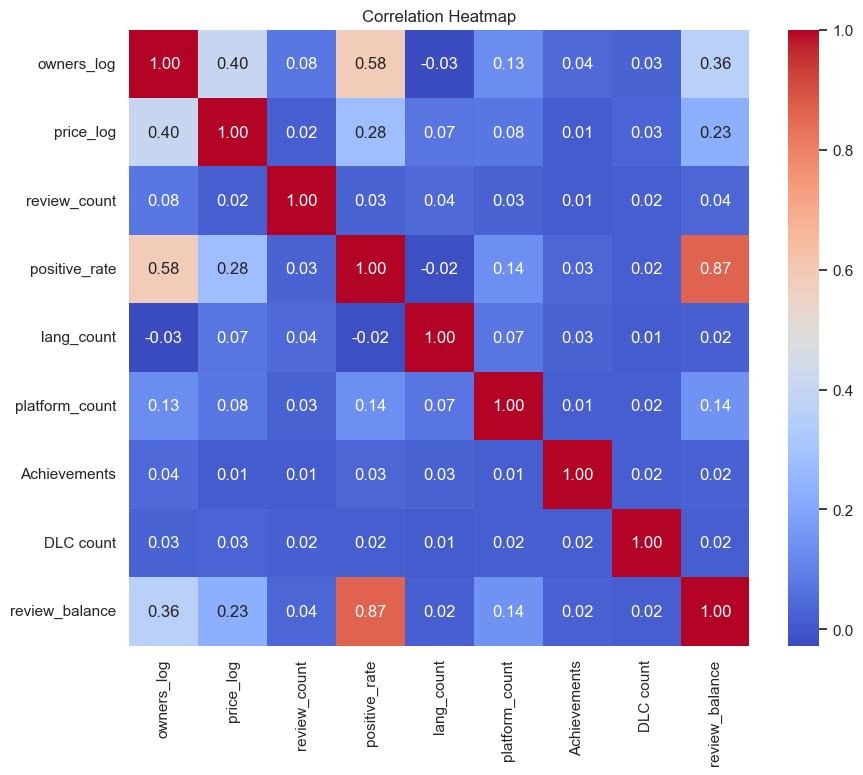

In [23]:
plt.figure(figsize=(10,8))
corr = df[["owners_log","price_log","review_count","positive_rate","lang_count",
           "platform_count","Achievements","DLC count","review_balance"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
